In [84]:
import time
import matplotlib.pyplot as plt

def _grabASCData(chnNo, bufSize):
    while True:
            # Wait until buffer is full
        if spm._dev.base.waitForFullBuffer(chnNo) != 0:
                break
    buffer = spm._dev.base.getDataBuffer(chnNo, 0, bufSize)
    values = buffer[3][:]
    meta = buffer[4]
    phys_vals = []
    unit = spm._dev.base.getUnitVal(meta)
    scaling = 1
    if 'Milli' in unit:
        scaling = 1e-3
    if 'Micro' in unit:
        scaling = 1e-6
    for val in values:
        phys_vals.append(spm._dev.base.convValue2Phys(meta, val)*scaling)
    return np.mean(phys_vals)

def _grabASCData_test(afm_int_time, chnNo, bufSize):
    pos1 = 1e-6
    pos2 = 2e-6
    spm._dev.base.setParameter(spm._dev.base.getConst('ID_REG_SET_Z_M'), pos1*1e12, 0)
    time.sleep(afm_int_time/2)
    spm._dev.base.setParameter(spm._dev.base.getConst('ID_REG_SET_Z_M'), pos2*1e12, 0)
    time.sleep(afm_int_time/2)
    while True:
            # Wait until buffer is full
        if spm._dev.base.waitForFullBuffer(chnNo) != 0:
                break
    buffer = spm._dev.base.getDataBuffer(chnNo, 0, bufSize)
    values = buffer[3][:]
    meta = buffer[4]
    phys_vals = []
    unit = spm._dev.base.getUnitVal(meta)
    scaling = 1
    if 'Milli' in unit:
        scaling = 1e-3
    if 'Micro' in unit:
        scaling = 1e-6
    for val in values:
        phys_vals.append(cur_Z_max_range-spm._dev.base.convValue2Phys(meta, val)*scaling)
    return phys_vals
    
def get_spm_channel_data(channel="CHANADC_AFMAMPL"):
    """Look in to the header file asc500.h for all the channel names"""
    spm._dev.base.configureChannel(11, # any Number between 0 and 13.
                            spm._dev.base.getConst('CHANCONN_PERMANENT'), # How you want to the data to be triggered
                            spm._dev.base.getConst('CHANADC_AFMAMPL'), #The Channel you want to get the data from
                            1, # 0/1 -  if you want to switch on averaging
                            1e-3) # Scanner sample time [s]
    spm._dev.base.configureDataBuffering(11, 256) # chNo = same as above; bufSize = Buffersize.
    # MAKE SURE BUFFER SIZE IS GREATER THAN 128 FOR TIME TRIGGERED DATA
    return _grabASCData(11, 256)

def setup_topography_measurement(afm_int_time = 1e-3):
    chNo = 11
    bufSize = 200
    spm._dev.base.configureChannel(11, # any Number between 0 and 13.
                            spm._dev.base.getConst('CHANCONN_PERMANENT'), # How you want to the data to be triggered
                            spm._dev.base.getConst('CHANADC_ZOUTINV'), #The Channel you want to get the data from
                            1, # 0/1 -  if you want to switch on averaging
                            afm_int_time/bufSize) # Scanner sample time [s]
    spm._dev.base.configureDataBuffering(chNo, bufSize) # chNo = same as above; bufSize = Buffersize.
    # MAKE SURE BUFFER SIZE IS GREATER THAN 128 FOR TIME TRIGGERED DATA
    return chNo, bufSize

def get_height():
    cur_height = 0
    N = 10
    for i in range(N):
        cur_height += spm._dev.base.getParameter(spm._dev.base.getConst('ID_REG_GET_Z_M'),0)*1e-12 # in m
    cur_height /= N
    return cur_height


In [90]:
afm_int_time = 100e-3
topo_channel, topo_bufsize = setup_topography_measurement(afm_int_time)
cur_Z_max_range = spm._dev.base.getParameter(spm._dev.base.getConst('ID_REG_ZABS_LIMM'), 0)*1e-12

In [91]:
topo = _grabASCData(topo_channel, topo_bufsize)
cur_height = get_height()
cur_topo = cur_Z_max_range-topo
print(f'Current Z range: {cur_Z_max_range} m')
print(f'Height from _grabASCData: {topo} m')
print(f'Corrected height from _grabASCData: {cur_topo} m')
print(f'Height from get_height: {cur_height} m')

Current Z range: 3.5e-06 m
Height from _grabASCData: 1.4996999502182006e-06 m
Corrected height from _grabASCData: 2.0003000497817993e-06 m
Height from get_height: 1.999873e-06 m


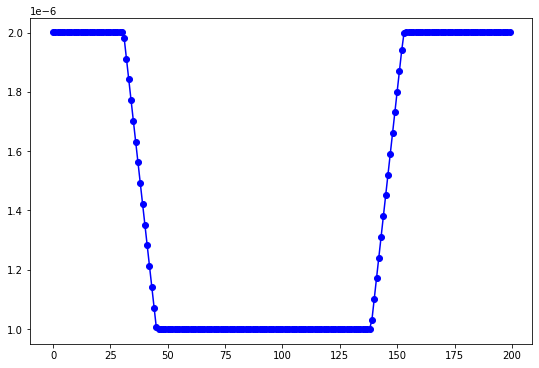

In [93]:
topo_buffer = _grabASCData_test(afm_int_time, topo_channel, topo_bufsize)
plt.plot(topo_buffer,'bo-')
plt.show()

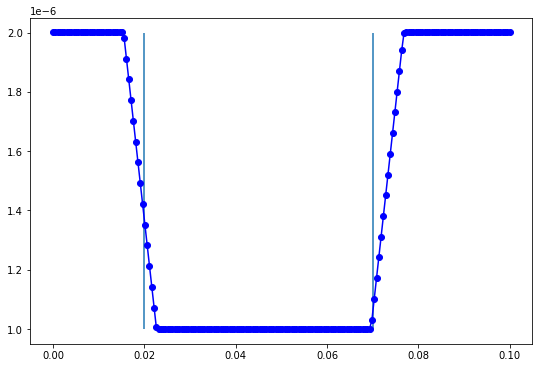

In [102]:
import numpy as np
t = np.linspace(0,afm_int_time, topo_bufsize)
plt.plot(t, topo_buffer, 'bo-')
plt.vlines([0.02, 0.02+afm_int_time/2], [1e-6,1e-6], [2e-6,2e-6])
plt.show()